# BD-KDD Dataset — Exploratory Data Analysis

## Objective

Perform a systematic exploratory data analysis of the BD-KDD clinical dataset before
applying any preprocessing or DODA-based feature selection.

The analysis will focus on:

- Dataset structure
- Data types
- Missing values
- Duplicate records
- Class distribution
- Numerical and categorical variables
- Clinical plausibility of values
- Outliers
- Feature relationships
- Potential data leakage
- Data-quality issues

The raw dataset will remain unchanged.

A cleaned version will be saved separately in the `data/processed/` directory.

In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Plotting defaults
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project Paths

The raw dataset is read from `data/raw/`.

The original file will not be modified during EDA.

Processed data will later be written to `data/processed/`.

In [6]:
# ============================================
# 2. CHECK CURRENT WORKING DIRECTORY
# ============================================

from pathlib import Path

PROJECT_ROOT = Path.cwd()

print("Current working directory:")
print(PROJECT_ROOT)

Current working directory:
c:\Users\johnm\msc_research\notebooks\angel\kidney_disease


In [12]:
# ============================================
# 2. LOCATE PROJECT ROOT
# ============================================

from pathlib import Path

# Current notebook working directory
CURRENT_DIR = Path.cwd()

print("Current working directory:")
print(CURRENT_DIR)

print("\nParent directories:")

for i, parent in enumerate(CURRENT_DIR.parents):
    print(f"parents[{i}] -> {parent}")

# Based on your folder structure:
# kidney_disease -> angel -> notebooks -> msc_research
PROJECT_ROOT = CURRENT_DIR.parents[2]

print("\nProject root:")
print(PROJECT_ROOT)

print("\nDoes project root exist?")
print(PROJECT_ROOT.exists())

print("\nContents of project root:")

if PROJECT_ROOT.exists():
    for item in PROJECT_ROOT.iterdir():
        print(f"  - {item.name}")

Current working directory:
c:\Users\johnm\msc_research\notebooks\angel\kidney_disease

Parent directories:
parents[0] -> c:\Users\johnm\msc_research\notebooks\angel
parents[1] -> c:\Users\johnm\msc_research\notebooks
parents[2] -> c:\Users\johnm\msc_research
parents[3] -> c:\Users\johnm
parents[4] -> c:\Users
parents[5] -> c:\

Project root:
c:\Users\johnm\msc_research

Does project root exist?
True

Contents of project root:
  - .git
  - .gitignore
  - .venv
  - CHANGELOG.md
  - config
  - CONTRIBUTING.md
  - docs
  - figures_tables
  - notebooks
  - pytest.ini
  - README.md
  - requirements
  - results
  - tests
  - venv


## 3. Load Raw Dataset

The original BD-KDD CSV is loaded without modification.

All exploratory analysis in this notebook will initially be performed on the raw dataset.

In [18]:
# ============================================
# 4. LOAD RAW DATASET
# ============================================

DATA_PATH = Path(r"C:\Users\johnm\msc_research\notebooks\data\raw\BD-KDD Dataset.csv")

print("Dataset path:")
print(DATA_PATH)

print("\nFile exists:", DATA_PATH.exists())

Dataset path:
C:\Users\johnm\msc_research\notebooks\data\raw\BD-KDD Dataset.csv

File exists: True


In [20]:
# ============================================
# 4. LOAD RAW DATASET
# ============================================

DATA_PATH = Path(r"C:\Users\johnm\msc_research\notebooks\data\raw\BD-KDD Dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"File: {DATA_PATH.name}")

Dataset loaded successfully.
File: BD-KDD Dataset.csv


## 4. Initial Inspection

Before performing any cleaning, inspect the first observations to understand
the structure and representation of the raw data.

In [21]:
# ============================================
# 5. FIRST 5 ROWS
# ============================================

display(df.head())

,Sl. No.,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,Bu,Sc,Sod,Pot,Hemo,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
0,1,58,147,1.025,1,3,0,1,0,0,177,76,5.820,132,4.570,9.300,43,12342,4.300,1,0,0,1,1,0,0
1,2,71,142,1.025,2,3,1,0,1,0,247,149,9.480,141,4.640,16.900,47,7249,3.700,0,1,1,0,1,1,1
2,3,48,179,1.005,0,4,1,1,0,1,367,109,2.810,132,4.750,16.600,37,4111,3.700,0,0,0,0,0,1,0
3,4,34,70,1.005,1,3,1,1,0,0,215,21,14.540,140,5.140,15.400,44,4682,4.000,1,0,1,1,0,1,1
4,5,62,120,1.020,4,0,1,0,1,0,143,75,13.760,141,5.160,13.900,54,5161,4.700,0,0,1,0,1,0,1


In [22]:
# ============================================
# 6. LAST 5 ROWS
# ============================================

display(df.tail())

,Sl. No.,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,Bu,Sc,Sod,Pot,Hemo,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
983,984,29,157,1.015,0,3,1,0,0,0,164,83,8.720,148,6.250,15.900,29,14801,4.900,0,1,1,0,0,1,0
984,985,29,72,1.005,3,4,0,1,1,0,295,55,5.640,139,4.660,9.600,49,12313,5.600,0,0,1,0,1,1,1
985,986,38,101,1.020,1,2,1,1,0,1,75,78,6.030,144,5.190,16.300,39,10105,4.800,0,1,1,1,0,1,1
986,987,36,168,1.015,2,4,0,1,0,1,283,123,6.470,140,5.910,12.900,48,6560,5.800,1,0,0,0,0,0,0
987,988,40,171,1.010,3,2,1,0,0,0,275,156,11.050,144,4.780,15.000,48,7037,5.100,0,0,1,0,1,0,1


In [23]:
# ============================================
# 7. DATASET DIMENSIONS
# ============================================

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")

Number of rows    : 988
Number of columns : 26


In [24]:
# ============================================
# 8. COLUMN NAMES
# ============================================

print("Column names:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Column names:

01. Sl. No.
02. Age
03. Bp
04. Sg
05. Al
06. Su
07. Rbc
08. Pc
09. Pcc
10. Ba
11. Bgr
12. Bu
13. Sc
14. Sod
15. Pot
16. Hemo
17. Pcv
18. Wbcc
19. Rbcc
20. Htn
21. Dm
22. Cad
23. Appet
24. Pe
25. Ane
26. Class


In [25]:
# ============================================
# 9. DATA TYPES
# ============================================

display(
    df.dtypes.to_frame(name="Data Type")
)

,Data Type
Sl. No.,int64
Age,int64
Bp,int64
Sg,float64
Al,int64
Su,int64
Rbc,int64
Pc,int64
Pcc,int64
Ba,int64


In [26]:
# ============================================
# 10. DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 988 entries, 0 to 987
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Sl. No.  988 non-null    int64  
 1   Age      988 non-null    int64  
 2   Bp       988 non-null    int64  
 3   Sg       988 non-null    float64
 4   Al       988 non-null    int64  
 5   Su       988 non-null    int64  
 6   Rbc      988 non-null    int64  
 7   Pc       988 non-null    int64  
 8   Pcc      988 non-null    int64  
 9   Ba       988 non-null    int64  
 10  Bgr      988 non-null    int64  
 11  Bu       988 non-null    int64  
 12  Sc       988 non-null    float64
 13  Sod      988 non-null    int64  
 14  Pot      988 non-null    float64
 15  Hemo     988 non-null    float64
 16  Pcv      988 non-null    int64  
 17  Wbcc     988 non-null    int64  
 18  Rbcc     988 non-null    float64
 19  Htn      988 non-null    int64  
 20  Dm       988 non-null    int64  
 21  Cad      988 non-null    in

## 5. Missing-Value Analysis

Missing values are inspected before any imputation or deletion.

No missing values will be modified at this stage.

In [27]:
# ============================================
# 11. MISSING VALUES
# ============================================

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary.sort_values(
    "Missing Count",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
Sl. No.,0,0.000
Age,0,0.000
Bp,0,0.000
Sg,0,0.000
Al,0,0.000
Su,0,0.000
Rbc,0,0.000
Pc,0,0.000
Pcc,0,0.000
Ba,0,0.000


In [28]:
# ============================================
# 12. TOTAL MISSING VALUES
# ============================================

print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [29]:
# ============================================
# 13. POSSIBLE HIDDEN MISSING VALUES
# ============================================

missing_tokens = [
    "?",
    "NA",
    "N/A",
    "na",
    "n/a",
    "Unknown",
    "unknown",
    "-",
    ""
]

for token in missing_tokens:
    count = (df.astype(str) == token).sum().sum()
    
    if count > 0:
        print(f"{token!r}: {count} occurrence(s)")

In [30]:
# ============================================
# 14. DUPLICATE ROWS
# ============================================

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(df) * 100:.2f}%"
)

Duplicate rows: 0
Duplicate percentage: 0.00%


In [31]:
# ============================================
# 15. UNIQUE VALUE COUNTS
# ============================================

unique_summary = pd.DataFrame({
    "Unique Values": df.nunique(dropna=False),
    "Data Type": df.dtypes
})

display(unique_summary)

,Unique Values,Data Type
Sl. No.,988,int64
Age,60,int64
Bp,110,int64
Sg,5,float64
Al,5,int64
Su,5,int64
Rbc,2,int64
Pc,2,int64
Pcc,2,int64
Ba,2,int64


In [32]:
# ============================================
# 16. TARGET VARIABLE
# ============================================

print("Target variable: Class\n")

print(df["Class"].value_counts(dropna=False))

Target variable: Class

Class
1    507
0    481
Name: count, dtype: int64


In [33]:
# ============================================
# 17. TARGET DISTRIBUTION
# ============================================

target_distribution = pd.DataFrame({
    "Count": df["Class"].value_counts(dropna=False),
    "Percentage": df["Class"].value_counts(
        normalize=True,
        dropna=False
    ) * 100
})

display(target_distribution)

,Count,Percentage
Class,,
1,507,51.316
0,481,48.684


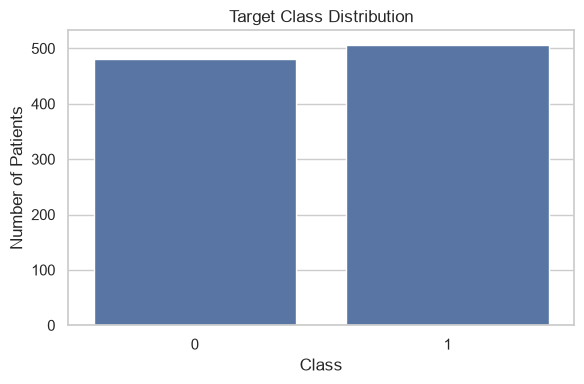

In [34]:
# ============================================
# 18. TARGET DISTRIBUTION PLOT
# ============================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()